<a href="https://colab.research.google.com/github/dimasdaywin/Portofolio-Data-Analysis-and-Deep-Learning/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50V2, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time # <<< Tambahkan ini untuk mengukur waktu pelatihan
import pandas as pd # <<< Tambahkan ini untuk membuat tabel

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


In [ ]:
print("--- 1. Pengunduhan dan Ekstraksi Dataset ---")

# URL dataset
dataset_url = "http://103.147.92.136/dw/dataset.zip"

# Nama file lokal
zip_file_name = "dataset.zip"
extract_path = "electronic_waste_dataset" # Folder tempat dataset akan diekstrak

print(f"Mengunduh dataset dari: {dataset_url}")
try:
    response = requests.get(dataset_url)
    response.raise_for_status() # Cek jika ada error HTTP
    with open(zip_file_name, 'wb') as f:
        f.write(response.content)
    print(f"Dataset '{zip_file_name}' berhasil diunduh.")

    print(f"Mengekstrak dataset ke: {extract_path}")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Ekstraksi selesai.")

except requests.exceptions.RequestException as e:
    print(f"Gagal mengunduh dataset: {e}")
except zipfile.BadZipFile:
    print(f"File '{zip_file_name}' bukan file ZIP yang valid atau rusak.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")


data_dir = os.path.join(extract_path, 'dataset')

if not os.path.exists(data_dir):
    print(f"Error: Direktori '{data_dir}' tidak ditemukan. Pastikan ekstraksi berhasil dan path benar.")
else:
    print(f"Dataset siap digunakan dari direktori: {data_dir}")

--- 1. Pengunduhan dan Ekstraksi Dataset ---
Mengunduh dataset dari: http://103.147.92.136/dw/dataset.zip
Dataset 'dataset.zip' berhasil diunduh.
Mengekstrak dataset ke: electronic_waste_dataset
Ekstraksi selesai.
Dataset siap digunakan dari direktori: electronic_waste_dataset/dataset



--- 2. Eksplorasi Dataset ---
Kelas-kelas yang terdeteksi: ['Keyboards', 'Mobile', 'Mouses', 'TV', 'camera', 'laptop', 'microwave', 'smartwatch']
Jumlah kelas: 8
  Keyboards: 110 gambar
  Mobile: 152 gambar
  Mouses: 104 gambar
  TV: 131 gambar
  camera: 62 gambar
  laptop: 117 gambar
  microwave: 102 gambar
  smartwatch: 100 gambar

Total gambar dalam dataset: 878


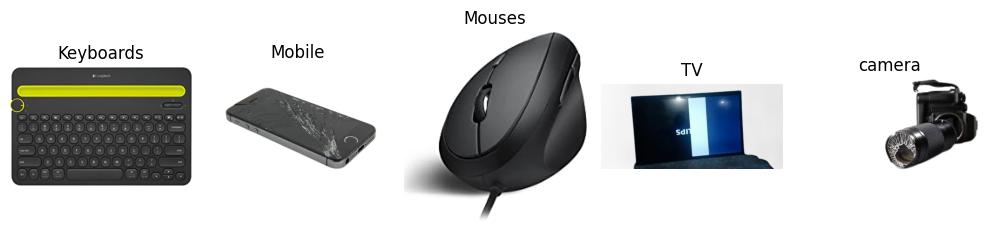


--- 3. Pra-proses Data & Persiapan Generator ---
Found 704 images belonging to 8 classes.
Found 173 images belonging to 8 classes.

Jumlah kelas yang terdeteksi: 8
Nama kelas: ['Keyboards', 'Mobile', 'Mouses', 'TV', 'camera', 'laptop', 'microwave', 'smartwatch']
Jumlah sampel training: 704
Jumlah sampel validation: 173


In [ ]:
print("\n--- 2. Eksplorasi Dataset ---")

if not os.path.exists(data_dir):
    print("Data directory not found. Please run the previous cell to extract the dataset.")
else:
    class_names = sorted(os.listdir(data_dir))
    print("Kelas-kelas yang terdeteksi:", class_names)
    print("Jumlah kelas:", len(class_names))

    total_images = 0
    images_per_class = {}
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            images_per_class[class_name] = num_images
            total_images += num_images
            print(f"  {class_name}: {num_images} gambar")

    print(f"\nTotal gambar dalam dataset: {total_images}")

    plt.figure(figsize=(10, 5))
    num_display_classes = min(5, len(class_names)) # Tampilkan maksimal 5 kelas
    for i, class_name in enumerate(class_names[:num_display_classes]):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            sample_image_name = os.listdir(class_path)[0] # Ambil 1 gambar pertama
            sample_image_path = os.path.join(class_path, sample_image_name)

            img = cv2.imread(sample_image_path)
            if img is None:
                print(f"Peringatan: Gagal membaca gambar {sample_image_path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, num_display_classes, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- 3. Pra-proses Data & Persiapan Generator ---
    print("\n--- 3. Pra-proses Data & Persiapan Generator ---")
    img_height = 224 # Ukuran standar untuk banyak model pre-trained
    img_width = 224
    batch_size = 32 # Ukuran batch, bisa disesuaikan tergantung memori GPU

    # Inisialisasi ImageDataGenerator dengan augmentasi dan normalisasi
    train_datagen = ImageDataGenerator(
        rescale=1./255, # Normalisasi piksel ke rentang [0, 1]
        validation_split=0.2, # 20% data untuk validasi
        # Augmentasi data (pengembangan pra-proses)
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Data generator untuk training
    train_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical', # Karena ini klasifikasi multi-kelas
        subset='training', # Set sebagai training subset
        seed=42 # Untuk reproduktifitas
    )

    # Data generator untuk validation (tanpa augmentasi, hanya normalisasi)
    val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    validation_generator = val_datagen.flow_from_directory(
        data_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation', # Set sebagai validation subset
        seed=42 # Untuk reproduktifitas
    )

    num_classes = len(class_names)
    print(f"\nJumlah kelas yang terdeteksi: {num_classes}")
    print(f"Nama kelas: {class_names}")
    print(f"Jumlah sampel training: {train_generator.samples}")
    print(f"Jumlah sampel validation: {validation_generator.samples}")


--- 2. Eksplorasi Dataset ---
Kelas-kelas yang terdeteksi: ['Keyboards', 'Mobile', 'Mouses', 'TV', 'camera', 'laptop', 'microwave', 'smartwatch']
Jumlah kelas: 8
  Keyboards: 110 gambar
  Mobile: 152 gambar
  Mouses: 104 gambar
  TV: 131 gambar
  camera: 62 gambar
  laptop: 117 gambar
  microwave: 102 gambar
  smartwatch: 100 gambar

Total gambar dalam dataset: 878


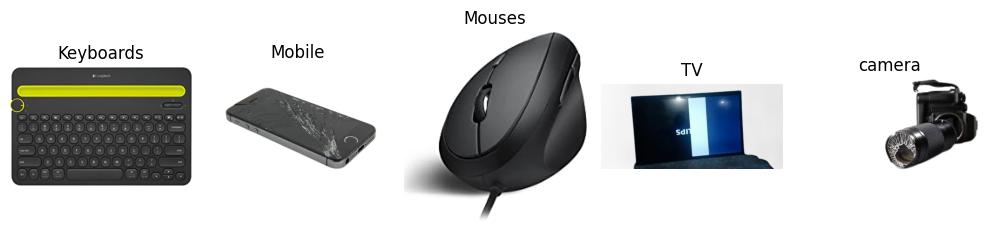


--- 3. Pra-proses Data & Persiapan Generator ---
Found 704 images belonging to 8 classes.
Found 173 images belonging to 8 classes.

Jumlah kelas yang terdeteksi: 8
Nama kelas: ['Keyboards', 'Mobile', 'Mouses', 'TV', 'camera', 'laptop', 'microwave', 'smartwatch']
Jumlah sampel training: 704
Jumlah sampel validation: 173


In [ ]:
# Eksplorasi Dataset dan Persiapan Generator Data

print("\n--- 2. Eksplorasi Dataset ---")

if not os.path.exists(data_dir):
    print("Data directory not found. Please run the previous cell to extract the dataset.")
else:
    class_names = sorted(os.listdir(data_dir))
    print("Kelas-kelas yang terdeteksi:", class_names)
    print("Jumlah kelas:", len(class_names))

    total_images = 0
    images_per_class = {}
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            images_per_class[class_name] = num_images
            total_images += num_images
            print(f"  {class_name}: {num_images} gambar")

    print(f"\nTotal gambar dalam dataset: {total_images}")

    # Contoh menampilkan beberapa gambar
    plt.figure(figsize=(10, 5))
    num_display_classes = min(5, len(class_names)) # Tampilkan maksimal 5 kelas
    for i, class_name in enumerate(class_names[:num_display_classes]):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            sample_image_name = os.listdir(class_path)[0] # Ambil 1 gambar pertama
            sample_image_path = os.path.join(class_path, sample_image_name)

            img = cv2.imread(sample_image_path)
            if img is None:
                print(f"Peringatan: Gagal membaca gambar {sample_image_path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, num_display_classes, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- 3. Pra-proses Data & Persiapan Generator ---
    print("\n--- 3. Pra-proses Data & Persiapan Generator ---")
    img_height = 224 # Ukuran standar untuk banyak model pre-trained
    img_width = 224
    batch_size = 32 # Ukuran batch, bisa disesuaikan tergantung memori GPU

    # Inisialisasi ImageDataGenerator dengan augmentasi dan normalisasi
    train_datagen = ImageDataGenerator(
        rescale=1./255, # Normalisasi piksel ke rentang [0, 1]
        validation_split=0.2, # 20% data untuk validasi
        # Augmentasi data (pengembangan pra-proses)
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Data generator untuk training
    train_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical', # Karena ini klasifikasi multi-kelas
        subset='training', # Set sebagai training subset
        seed=42 # Untuk reproduktifitas
    )

    # Data generator untuk validation (tanpa augmentasi, hanya normalisasi)
    val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    validation_generator = val_datagen.flow_from_directory(
        data_dir,
        target_size=(img_height, img_width),
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation', # Set sebagai validation subset
        seed=42 # Untuk reproduktifitas
    )

    num_classes = len(class_names)
    print(f"\nJumlah kelas yang terdeteksi: {num_classes}")
    print(f"Nama kelas: {class_names}")
    print(f"Jumlah sampel training: {train_generator.samples}")
    print(f"Jumlah sampel validation: {validation_generator.samples}")

    # Inisialisasi dictionary untuk menyimpan hasil semua model
    all_model_results = {} # <<< Tambahkan ini


--- 4.1 Membangun dan Melatih Model A: VGG16 ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,528 (80.64 MB)

 Trainable params: 6,424,840 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.2085 - loss: 2.2290
Epoch 1: val_loss improved from inf to 1.18258, saving model to best_model_vgg.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 873ms/step - accuracy: 0.2134 - loss: 2.2136 - val_accuracy: 0.6185 - val_loss: 1.1826
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.6017 - loss: 1.2004
Epoch 2: val_loss improved from 1.18258 to 0.73959, saving model to best_model_vgg.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 538ms/step - accuracy: 0.6032 - loss: 1.1961 - val_accuracy: 0.7803 - val_loss: 0.7396
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.7133 - loss: 0.8967
Epoch 3: val_loss improved from 0.73959 to 0.64365, saving model to best_model_vgg.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 567ms/step - accuracy: 0.7138 - loss: 0.8945 - val_accuracy: 0.7572 - val_loss: 0.6436
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.7630 - loss: 0.7454
Epoch 4: val_loss improved from 0.64365

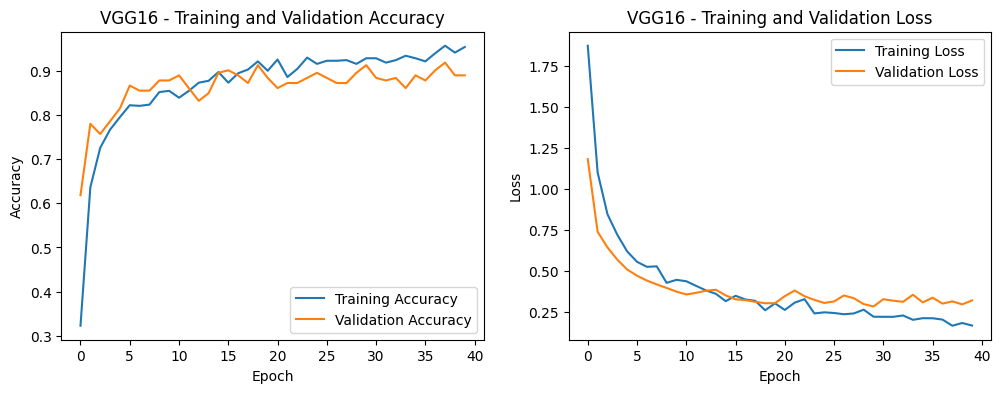

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step

Classification Report for VGG16:
              precision    recall  f1-score   support

   Keyboards       0.19      0.18      0.19        22
      Mobile       0.10      0.10      0.10        30
      Mouses       0.10      0.10      0.10        20
          TV       0.08      0.08      0.08        26
      camera       0.00      0.00      0.00        12
      laptop       0.08      0.09      0.09        23
   microwave       0.24      0.25      0.24        20
  smartwatch       0.05      0.05      0.05        20

    accuracy                           0.11       173
   macro avg       0.10      0.11      0.11       173
weighted avg       0.11      0.11      0.11       173



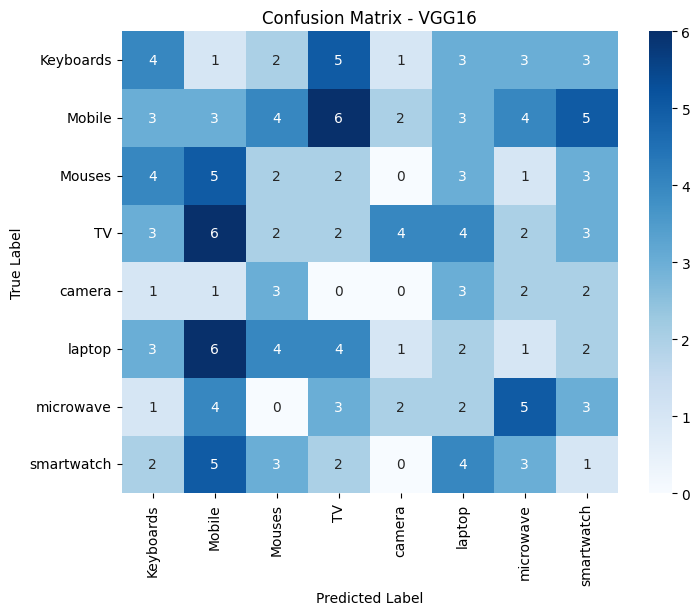

In [ ]:
# Pelatihan dan Evaluasi Model A (VGG16)

if 'train_generator' not in locals():
    print("Data generators not found. Please run previous cells.")
else:
    epochs = 50 # Jumlah epoch maksimum, EarlyStopping akan menghentikan lebih awal

    # --- Model A: VGG16 ---
    print("\n--- 4.1 Membangun dan Melatih Model A: VGG16 ---")
    base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model_vgg.layers:
        layer.trainable = False # Bekukan lapisan dasar

    x = base_model_vgg.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x) # Lapisan Dense
    x = Dropout(0.5)(x) # Dropout untuk mencegah overfitting
    predictions = Dense(num_classes, activation='softmax')(x) # Lapisan output

    model_vgg = Model(inputs=base_model_vgg.input, outputs=predictions)
    model_vgg.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    model_vgg.summary()

    start_time_vgg = time.time() # <<< Mulai hitung waktu
    history_vgg = model_vgg.fit(
        train_generator,
        epochs=epochs,
        validation_data=validation_generator,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
                   tf.keras.callbacks.ModelCheckpoint('best_model_vgg.keras', monitor='val_loss', save_best_only=True, verbose=1)]
    )
    end_time_vgg = time.time() # <<< Selesai hitung waktu
    training_time_vgg = end_time_vgg - start_time_vgg

    # Evaluasi Model A
    print("\n--- 4.1.1 Mengevaluasi Model A: VGG16 ---")
    loss_vgg, accuracy_vgg = model_vgg.evaluate(validation_generator)
    print(f"VGG16 - Validation Loss: {loss_vgg:.4f}")
    print(f"VGG16 - Validation Accuracy: {accuracy_vgg:.4f}")

    # Plot hasil pelatihan
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
    plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
    plt.title('VGG16 - Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history_vgg.history['loss'], label='Training Loss')
    plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
    plt.title('VGG16 - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    validation_generator.reset()
    y_pred_vgg_prob = model_vgg.predict(validation_generator)
    y_pred_vgg = np.argmax(y_pred_vgg_prob, axis=1)
    y_true_vgg = validation_generator.classes[validation_generator.index_array]
    report_vgg = classification_report(y_true_vgg, y_pred_vgg, target_names=class_names, output_dict=True) # <<< Ambil report sebagai dict
    f1_score_vgg = report_vgg['weighted avg']['f1-score'] * 100 # <<< Ambil F1-score (weighted avg)

    print("\nClassification Report for VGG16:")
    print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))
    cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - VGG16')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # <<< Simpan hasil ke dictionary global
    all_model_results['VGG16'] = {
        'accuracy': accuracy_vgg * 100, # dalam persen
        'val_loss': loss_vgg,
        'f1_score': f1_score_vgg, # dalam persen
        'speed_test': training_time_vgg,
        'history': history_vgg
    }


--- 4.2 Membangun dan Melatih Model B: ResNet50V2 ---
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 49,257,224 (187.90 MB)

 Trainable params: 25,692,424 (98.01 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.4760 - loss: 2.7891
Epoch 1: val_loss improved from inf to 0.41094, saving model to best_model_resnet.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4849 - loss: 2.7336 - val_accuracy: 0.8960 - val_loss: 0.4109
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.8904 - loss: 0.4566
Epoch 2: val_loss improved from 0.41094 to 0.26001, saving model to best_model_resnet.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 624ms/step - accuracy: 0.8900 - loss: 0.4577 - val_accuracy: 0.9191 - val_loss: 0.2600
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.8898 - loss: 0.3337
Epoch 3: val_loss did not improve from 0.26001
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 506ms/step - accuracy: 0.8905 - loss: 0.3321 - val_accuracy: 0.9017 - val_loss: 0.3061
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9185 - loss: 0.2291
Epoch 4: val_loss did not improve from 0.26001
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 

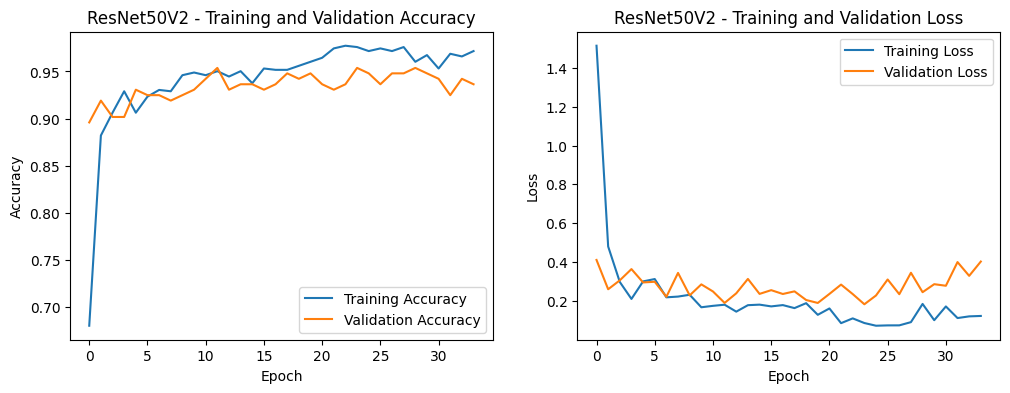

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 758ms/step

Classification Report for ResNet50V2:
              precision    recall  f1-score   support

   Keyboards       0.10      0.09      0.09        22
      Mobile       0.16      0.17      0.16        30
      Mouses       0.14      0.15      0.15        20
          TV       0.08      0.08      0.08        26
      camera       0.09      0.08      0.09        12
      laptop       0.15      0.17      0.16        23
   microwave       0.11      0.10      0.11        20
  smartwatch       0.16      0.15      0.15        20

    accuracy                           0.13       173
   macro avg       0.12      0.12      0.12       173
weighted avg       0.13      0.13      0.13       173



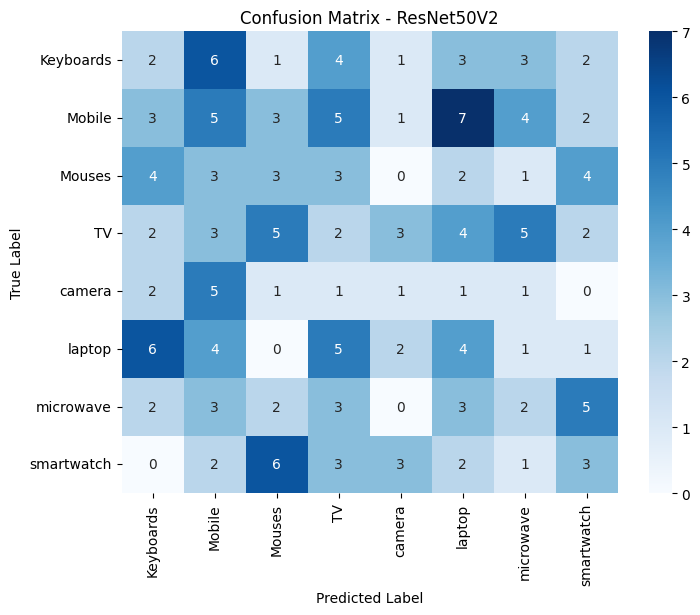

In [ ]:
# Pelatihan dan Evaluasi Model B (ResNet50V2)

if 'train_generator' not in locals():
    print("Data generators not found. Please run previous cells.")
else:
    epochs = 50 # Jumlah epoch maksimum, EarlyStopping akan menghentikan lebih awal

    # --- Model B: ResNet50V2 ---
    print("\n--- 4.2 Membangun dan Melatih Model B: ResNet50V2 ---")
    base_model_resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model_resnet.layers:
        layer.trainable = False

    x = base_model_resnet.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions)
    model_resnet.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    model_resnet.summary()

    start_time_resnet = time.time() # <<< Mulai hitung waktu
    history_resnet = model_resnet.fit(
        train_generator,
        epochs=epochs,
        validation_data=validation_generator,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
                   tf.keras.callbacks.ModelCheckpoint('best_model_resnet.keras', monitor='val_loss', save_best_only=True, verbose=1)]
    )
    end_time_resnet = time.time() # <<< Selesai hitung waktu
    training_time_resnet = end_time_resnet - start_time_resnet

    # Evaluasi Model B
    print("\n--- 4.2.1 Mengevaluasi Model B: ResNet50V2 ---")
    loss_resnet, accuracy_resnet = model_resnet.evaluate(validation_generator)
    print(f"ResNet50V2 - Validation Loss: {loss_resnet:.4f}")
    print(f"ResNet50V2 - Validation Accuracy: {accuracy_resnet:.4f}")

    # Plot hasil pelatihan
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
    plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
    plt.title('ResNet50V2 - Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history_resnet.history['loss'], label='Training Loss')
    plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
    plt.title('ResNet50V2 - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    validation_generator.reset()
    y_pred_resnet_prob = model_resnet.predict(validation_generator)
    y_pred_resnet = np.argmax(y_pred_resnet_prob, axis=1)
    y_true_resnet = validation_generator.classes[validation_generator.index_array]
    report_resnet = classification_report(y_true_resnet, y_pred_resnet, target_names=class_names, output_dict=True) # <<< Ambil report sebagai dict
    f1_score_resnet = report_resnet['weighted avg']['f1-score'] * 100 # <<< Ambil F1-score (weighted avg)

    print("\nClassification Report for ResNet50V2:")
    print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))
    cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - ResNet50V2')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # <<< Simpan hasil ke dictionary global
    all_model_results['ResNet50V2'] = {
        'accuracy': accuracy_resnet * 100, # dalam persen
        'val_loss': loss_resnet,
        'f1_score': f1_score_resnet, # dalam persen
        'speed_test': training_time_resnet,
        'history': history_resnet
    }


--- 4.3 Membangun dan Melatih Model C: MobileNetV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 18,316,616 (69.87 MB)

 Trainable params: 16,058,632 (61.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.4673 - loss: 2.0641
Epoch 1: val_loss improved from inf to 0.45339, saving model to best_model_mobilenet.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 846ms/step - accuracy: 0.4752 - loss: 2.0323 - val_accuracy: 0.8497 - val_loss: 0.4534
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8413 - loss: 0.5677
Epoch 2: val_loss improved from 0.45339 to 0.20223, saving model to best_model_mobilenet.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 561ms/step - accuracy: 0.8418 - loss: 0.5661 - val_accuracy: 0.9306 - val_loss: 0.2022
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8819 - loss: 0.3131
Epoch 3: val_loss did not improve from 0.20223
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 482ms/step - accuracy: 0.8821 - loss: 0.3132 - val_accuracy: 0.9075 - val_loss: 0.2264
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9391 - loss: 0.1762
Epoch 4: val_loss did not improve from 0.20223
22/22 ━━━━━━━━━━━━━━━━

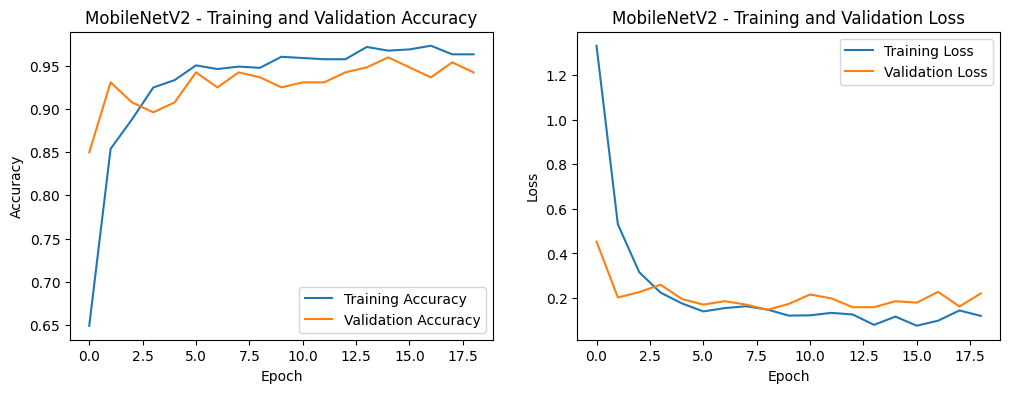

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 824ms/step

Classification Report for MobileNetV2:
              precision    recall  f1-score   support

   Keyboards       0.18      0.18      0.18        22
      Mobile       0.06      0.07      0.06        30
      Mouses       0.05      0.05      0.05        20
          TV       0.15      0.15      0.15        26
      camera       0.00      0.00      0.00        12
      laptop       0.04      0.04      0.04        23
   microwave       0.15      0.15      0.15        20
  smartwatch       0.15      0.15      0.15        20

    accuracy                           0.10       173
   macro avg       0.10      0.10      0.10       173
weighted avg       0.10      0.10      0.10       173



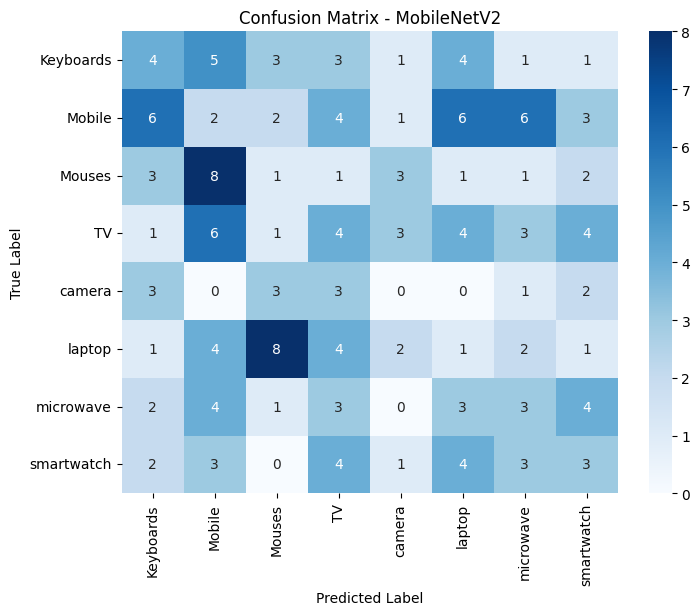

In [ ]:
# Pelatihan dan Evaluasi Model C (MobileNetV2)

if 'train_generator' not in locals():
    print("Data generators not found. Please run previous cells.")
else:
    epochs = 50

    # --- Model C: MobileNetV2 ---
    print("\n--- 4.3 Membangun dan Melatih Model C: MobileNetV2 ---")
    base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model_mobilenet.layers:
        layer.trainable = False

    x = base_model_mobilenet.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=predictions)
    model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    model_mobilenet.summary()

    start_time_mobilenet = time.time() # <<< Mulai hitung waktu
    history_mobilenet = model_mobilenet.fit(
        train_generator,
        epochs=epochs,
        validation_data=validation_generator,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
                   tf.keras.callbacks.ModelCheckpoint('best_model_mobilenet.keras', monitor='val_loss', save_best_only=True, verbose=1)]
    )
    end_time_mobilenet = time.time() # <<< Selesai hitung waktu
    training_time_mobilenet = end_time_mobilenet - start_time_mobilenet

    # Evaluasi Model C
    print("\n--- 4.3.1 Mengevaluasi Model C: MobileNetV2 ---")
    loss_mobilenet, accuracy_mobilenet = model_mobilenet.evaluate(validation_generator)
    print(f"MobileNetV2 - Validation Loss: {loss_mobilenet:.4f}")
    print(f"MobileNetV2 - Validation Accuracy: {accuracy_mobilenet:.4f}")

    # Plot hasil pelatihan
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
    plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
    plt.title('MobileNetV2 - Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history_mobilenet.history['loss'], label='Training Loss')
    plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
    plt.title('MobileNetV2 - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    validation_generator.reset()
    y_pred_mobilenet_prob = model_mobilenet.predict(validation_generator)
    y_pred_mobilenet = np.argmax(y_pred_mobilenet_prob, axis=1)
    y_true_mobilenet = validation_generator.classes[validation_generator.index_array]
    report_mobilenet = classification_report(y_true_mobilenet, y_pred_mobilenet, target_names=class_names, output_dict=True) # <<< Ambil report sebagai dict
    f1_score_mobilenet = report_mobilenet['weighted avg']['f1-score'] * 100 # <<< Ambil F1-score (weighted avg)

    print("\nClassification Report for MobileNetV2:")
    print(classification_report(y_true_mobilenet, y_pred_mobilenet, target_names=class_names))
    cm_mobilenet = confusion_matrix(y_true_mobilenet, y_pred_mobilenet)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - MobileNetV2')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # <<< Simpan hasil ke dictionary global
    all_model_results['MobileNetV2'] = {
        'accuracy': accuracy_mobilenet * 100, # dalam persen
        'val_loss': loss_mobilenet,
        'f1_score': f1_score_mobilenet, # dalam persen
        'speed_test': training_time_mobilenet,
        'history': history_mobilenet
    }


--- 5. Pengembangan: Hyperparameter Tuning (Learning Rate) untuk ResNet50V2 ---

--- Melatih ResNet50V2 dengan Learning Rate: 0.0005 ---
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.4380 - loss: 7.0352
Epoch 1: val_loss improved from inf to 0.59027, saving model to best_model_resnet_lr_0.0005.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 861ms/step - accuracy: 0.4457 - loss: 6.9403 - val_accuracy: 0.9075 - val_loss: 0.5903
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8548 - loss: 1.1480
Epoch 2: val_loss did not improve from 0.59027
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 487ms/step - accuracy: 0.8544 - loss: 1.1517 - val_accuracy: 0.8844 - val_loss: 1.1923
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8947 - loss: 0.5291
Epoch 3: val_loss improved from 0.59027 to 0.27083, saving model to best_model_resnet_lr_0.0005.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 623ms/step - accuracy: 0.8946 - loss: 0.5315 - val_accuracy: 0.9191 - val_loss: 0.2708
Epo

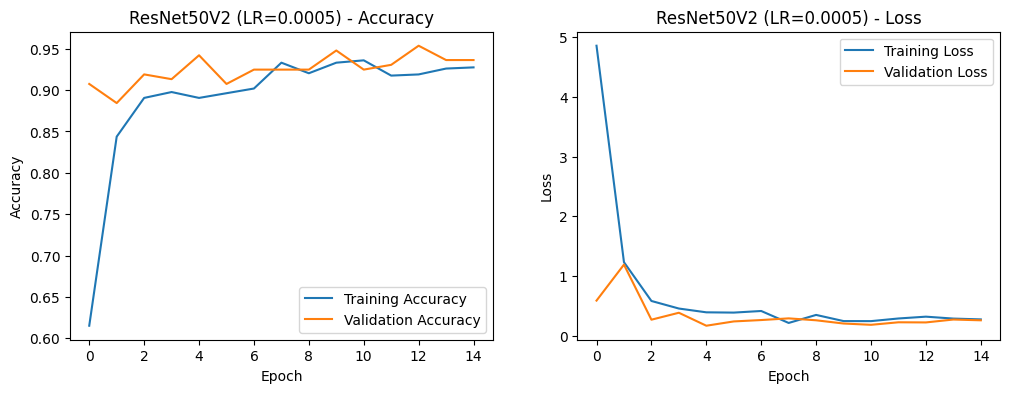


--- Melatih ResNet50V2 dengan Learning Rate: 1e-05 ---
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.1938 - loss: 4.3792
Epoch 1: val_loss improved from inf to 0.95951, saving model to best_model_resnet_lr_1e-05.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.1981 - loss: 4.3324 - val_accuracy: 0.6936 - val_loss: 0.9595
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.5132 - loss: 1.6793
Epoch 2: val_loss improved from 0.95951 to 0.49229, saving model to best_model_resnet_lr_1e-05.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 722ms/step - accuracy: 0.5161 - loss: 1.6737 - val_accuracy: 0.8382 - val_loss: 0.4923
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.7304 - loss: 0.8965
Epoch 3: val_loss improved from 0.49229 to 0.35572, saving model to best_model_resnet_lr_1e-05.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 741ms/step - accuracy: 0.7312 - loss: 0.8947 - val_accuracy: 0.8786 - val_loss: 0.3557
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━

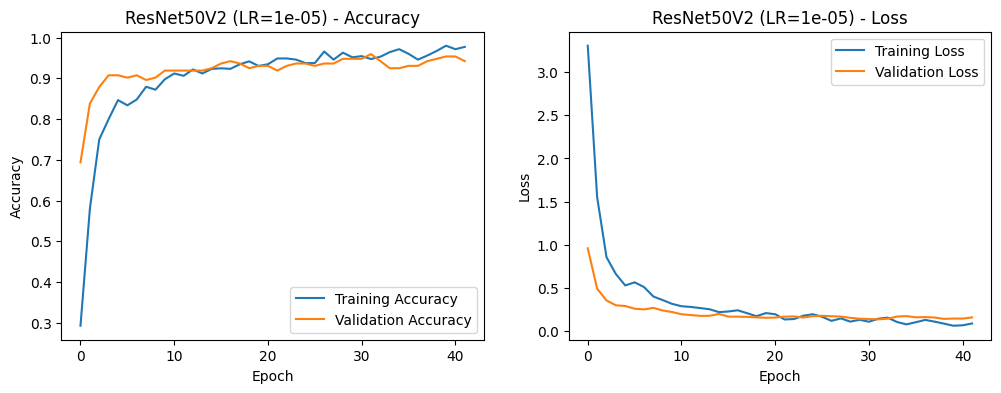


--- Ringkasan Hasil Hyperparameter Tuning ---
ResNet50V2_LR_0.0005: Accuracy = 0.9422, Loss = 0.1700
ResNet50V2_LR_1e-05: Accuracy = 0.9595, Loss = 0.1371


In [ ]:
if 'train_generator' not in locals():
    print("Data generators not found. Please run previous cells.")
else:
    print("\n--- 5. Pengembangan: Hyperparameter Tuning (Learning Rate) untuk ResNet50V2 ---")

    # Kita akan mencoba beberapa learning rates berbeda untuk ResNet50V2
    learning_rates = [0.0005, 0.00001]

    results_tuning = {}
    epochs = 50 # Jumlah epoch maksimum untuk tuning

    for lr in learning_rates:
        print(f"\n--- Melatih ResNet50V2 dengan Learning Rate: {lr} ---")

        # Muat ulang base model (penting untuk memastikan pelatihan dimulai dari awal untuk LR baru)
        base_model_resnet_tuned = ResNet50V2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
        for layer in base_model_resnet_tuned.layers:
            layer.trainable = False

        x = base_model_resnet_tuned.output
        x = Flatten()(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.5)(x)
        predictions = Dense(num_classes, activation='softmax')(x)

        model_resnet_tuned = Model(inputs=base_model_resnet_tuned.input, outputs=predictions)

        # Compile dengan learning rate baru
        model_resnet_tuned.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

        history_tuned = model_resnet_tuned.fit(
            train_generator,
            epochs=epochs,
            validation_data=validation_generator,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
                       tf.keras.callbacks.ModelCheckpoint(f'best_model_resnet_lr_{lr}.keras', monitor='val_loss', save_best_only=True, verbose=1)]
        )

        loss_tuned, accuracy_tuned = model_resnet_tuned.evaluate(validation_generator)
        results_tuning[f'ResNet50V2_LR_{lr}'] = {'loss': loss_tuned, 'accuracy': accuracy_tuned, 'history': history_tuned} # <<< Simpan hasil tuning

        print(f"ResNet50V2 (LR={lr}) - Validation Accuracy: {accuracy_tuned:.4f}")

        # Plot hasil tuning
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history_tuned.history['accuracy'], label='Training Accuracy')
        plt.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
        plt.title(f'ResNet50V2 (LR={lr}) - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(history_tuned.history['loss'], label='Training Loss')
        plt.plot(history_tuned.history['val_loss'], label='Validation Loss')
        plt.title(f'ResNet50V2 (LR={lr}) - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    # Ringkasan hasil tuning
    print("\n--- Ringkasan Hasil Hyperparameter Tuning ---")
    for lr_key, res in results_tuning.items():
        print(f"{lr_key}: Accuracy = {res['accuracy']:.4f}, Loss = {res['loss']:.4f}")


--- 6. Visualisasi Akurasi Validasi Komparatif ---


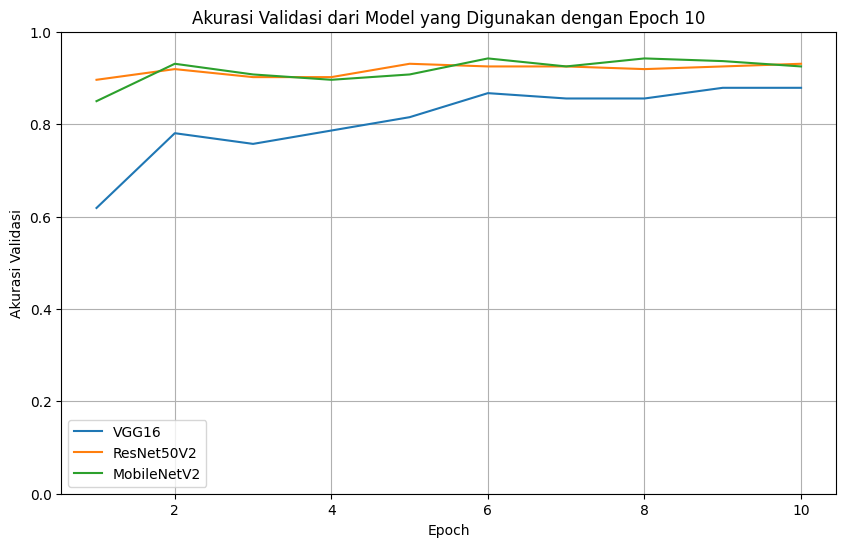

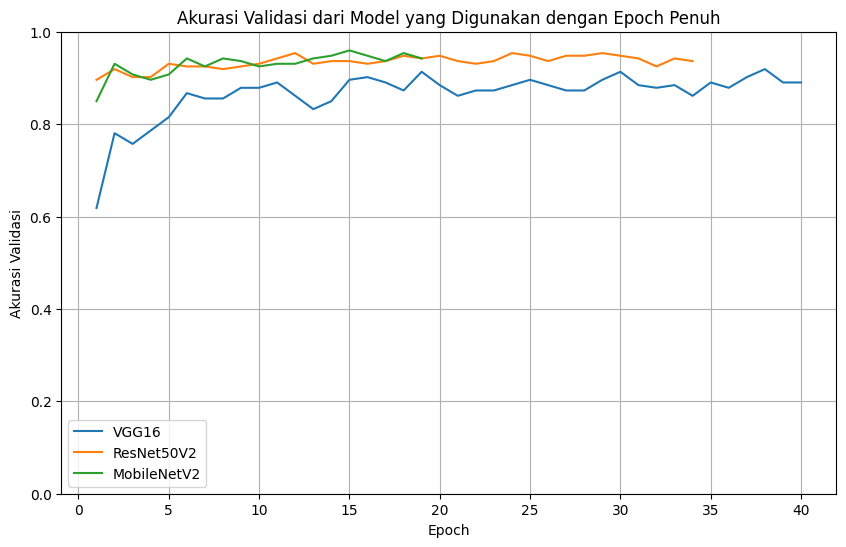

In [ ]:
if 'all_model_results' not in locals() or not all_model_results:
    print("No model results found. Please run previous training cells.")
else:
    print("\n--- 6. Visualisasi Akurasi Validasi Komparatif ---")

    # Plot untuk 10 epoch pertama (mirip Gambar 1)
    plt.figure(figsize=(10, 6))
    for model_name, results in all_model_results.items():
        history = results['history']
        val_accuracy = history.history['val_accuracy']
        epochs_to_plot = min(10, len(val_accuracy)) # Plot hingga 10 epoch atau kurang jika pelatihan berhenti lebih awal
        plt.plot(range(1, epochs_to_plot + 1), val_accuracy[:epochs_to_plot], label=model_name)

    plt.title('Akurasi Validasi dari Model yang Digunakan dengan Epoch 10')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi Validasi')
    plt.ylim([0, 1]) # Akurasi antara 0 dan 1
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot untuk semua epoch (mirip Gambar 2)
    plt.figure(figsize=(10, 6))
    for model_name, results in all_model_results.items():
        history = results['history']
        val_accuracy = history.history['val_accuracy']
        plt.plot(range(1, len(val_accuracy) + 1), val_accuracy, label=model_name)

    plt.title('Akurasi Validasi dari Model yang Digunakan dengan Epoch Penuh')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi Validasi')
    plt.ylim([0, 1])
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Cell 9: Matriks Evaluasi Per Model

if 'all_model_results' not in locals() or not all_model_results:
    print("No model results found. Please run previous training cells.")
else:
    print("\n--- 7. Matriks Evaluasi Per Model ---")

    data_for_table = []
    for model_name, results in all_model_results.items():
        data_for_table.append({
            'Model': model_name,
            'Akurasi (%)': f"{results['accuracy']:.2f}",
            'val_loss': f"{results['val_loss']:.3f}",
            'F1-score (%)': f"{results['f1_score']:.0f}", # Dibulatkan ke integer
            'Speed test (s)': f"{results['speed_test']:.0f}" # Dibulatkan ke integer
        })

    df_results = pd.DataFrame(data_for_table)
    print("Tabel Matriks evaluasi per Model:")
    print(df_results.to_string(index=False)) # to_string() untuk memastikan tabel ditampilkan penuh


--- 7. Matriks Evaluasi Per Model ---
Tabel Matriks evaluasi per Model:
      Model Akurasi (%) val_loss F1-score (%) Speed test (s)
      VGG16       91.33    0.283           11            533
 ResNet50V2       95.38    0.183           13            554
MobileNetV2       93.64    0.147           10            271
